## VALIDATION CURVE — MASTER CODE

### Imports & Dataset

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.datasets import load_breast_cancer
from sklearn.model_selection import validation_curve
from sklearn.linear_model import LogisticRegression
from sklearn.svm import SVC
from sklearn.ensemble import RandomForestClassifier

sns.set(style="whitegrid")
np.random.seed(42)


In [2]:
# Dataset
data = load_breast_cancer()
X = data.data
y = data.target


### Basic Validation Curve (Logistic Regression — C)

In [3]:
param_range = np.logspace(-3, 3, 7)

model = LogisticRegression(max_iter=4000)

train_scores, val_scores = validation_curve(
    model,
    X,
    y,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

train_mean = train_scores.mean(axis=1)
val_mean = val_scores.mean(axis=1)


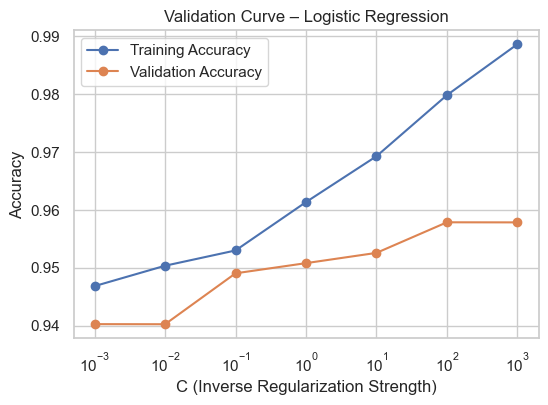

In [4]:
plt.figure(figsize=(6, 4))
plt.semilogx(param_range, train_mean, "o-", label="Training Accuracy")
plt.semilogx(param_range, val_mean, "o-", label="Validation Accuracy")
plt.xlabel("C (Inverse Regularization Strength)")
plt.ylabel("Accuracy")
plt.title("Validation Curve – Logistic Regression")
plt.legend()
plt.show()


### Validation Curve with Variance (Error Bands)

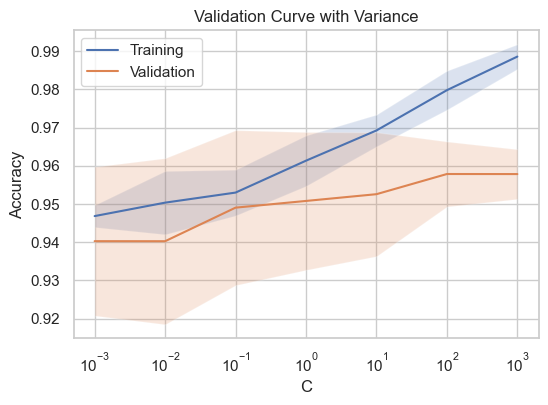

In [5]:
train_std = train_scores.std(axis=1)
val_std = val_scores.std(axis=1)

plt.figure(figsize=(6, 4))
plt.fill_between(
    param_range,
    train_mean - train_std,
    train_mean + train_std,
    alpha=0.2
)
plt.fill_between(
    param_range,
    val_mean - val_std,
    val_mean + val_std,
    alpha=0.2
)
plt.semilogx(param_range, train_mean, label="Training")
plt.semilogx(param_range, val_mean, label="Validation")
plt.xlabel("C")
plt.ylabel("Accuracy")
plt.title("Validation Curve with Variance")
plt.legend()
plt.show()


### Overfitting Example (SVM — gamma)

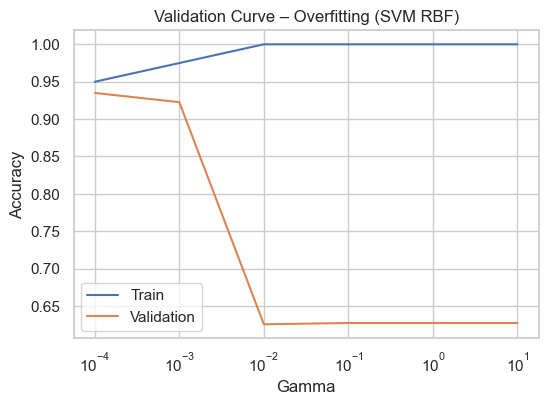

In [6]:
gamma_range = np.logspace(-4, 1, 6)

svm = SVC(kernel="rbf")

train_scores, val_scores = validation_curve(
    svm,
    X,
    y,
    param_name="gamma",
    param_range=gamma_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

plt.figure(figsize=(6, 4))
plt.semilogx(gamma_range, train_scores.mean(axis=1), label="Train")
plt.semilogx(gamma_range, val_scores.mean(axis=1), label="Validation")
plt.xlabel("Gamma")
plt.ylabel("Accuracy")
plt.title("Validation Curve – Overfitting (SVM RBF)")
plt.legend()
plt.show()


### Underfitting Example (Random Forest — max_depth)

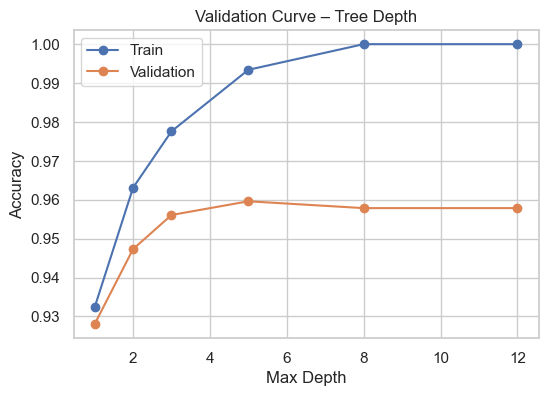

In [7]:
depth_range = [1, 2, 3, 5, 8, 12, None]

rf = RandomForestClassifier(n_estimators=200, random_state=42)

train_scores, val_scores = validation_curve(
    rf,
    X,
    y,
    param_name="max_depth",
    param_range=depth_range,
    cv=5,
    scoring="accuracy",
    n_jobs=-1
)

plt.figure(figsize=(6, 4))
plt.plot(depth_range, train_scores.mean(axis=1), "o-", label="Train")
plt.plot(depth_range, val_scores.mean(axis=1), "o-", label="Validation")
plt.xlabel("Max Depth")
plt.ylabel("Accuracy")
plt.title("Validation Curve – Tree Depth")
plt.legend()
plt.show()


### Compare Hyperparameters Across Models (Validation Only)

TypeError: too many positional arguments

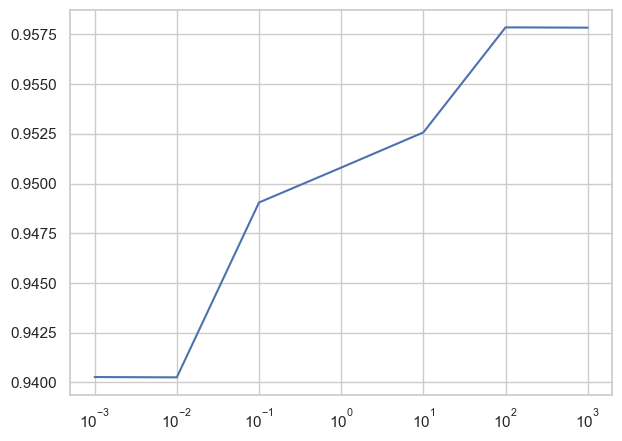

In [8]:
plt.figure(figsize=(7, 5))

# Logistic Regression (C)
plt.semilogx(
    param_range,
    val_mean,
    label="Logistic (C)"
)

# SVM (gamma)
plt.semilogx(
    gamma_range,
    validation_curve(
        SVC(kernel="rbf"),
        X, y,
        "gamma", gamma_range,
        cv=5, scoring="accuracy", n_jobs=-1
    )[1].mean(axis=1),
    label="SVM (gamma)"
)

plt.xlabel("Hyperparameter Scale (log)")
plt.ylabel("Validation Accuracy")
plt.title("Validation Curve Comparison (Validation)")
plt.legend()
plt.show()


### Validation Curve with Loss (Log Loss)

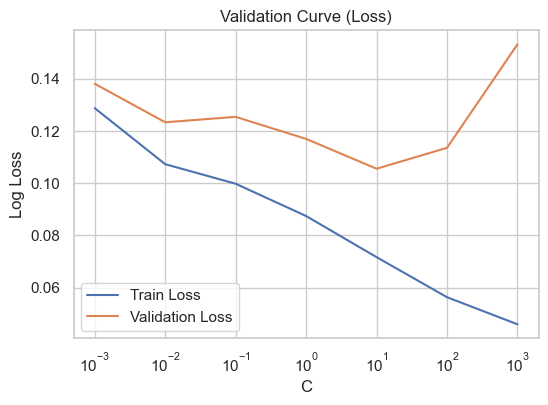

In [9]:
model = LogisticRegression(max_iter=4000)

param_range = np.logspace(-3, 3, 7)

train_scores, val_scores = validation_curve(
    model,
    X,
    y,
    param_name="C",
    param_range=param_range,
    cv=5,
    scoring="neg_log_loss",
    n_jobs=-1
)

plt.figure(figsize=(6, 4))
plt.semilogx(param_range, -train_scores.mean(axis=1), label="Train Loss")
plt.semilogx(param_range, -val_scores.mean(axis=1), label="Validation Loss")
plt.xlabel("C")
plt.ylabel("Log Loss")
plt.title("Validation Curve (Loss)")
plt.legend()
plt.show()
